In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# Load cleaned dataset
df = pd.read_csv("../data/cleaned/layoffs_cleaned.csv")

df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,month,year_month
0,Pentera,Boston,40.0,2026-04-27,0.08,Security,https://www.calcalistech.com/ctechnews/article...,Series D,249.0,United States,4/30/2026,2026.0,4.0,2026-04
1,SuperOps,"Chennai, Non-U.S.",60.0,2026-04-24,0.30,Other,https://inc42.com/buzz/superops-lays-off-30-st...,Series C,54.0,India,4/30/2026,2026.0,4.0,2026-04
2,Acko,"Mumbai, Non-U.S.",60.0,2026-04-20,0.05,Finance,https://inc42.com/buzz/acko-cuts-5-workforce-i...,Unknown,143.0,India,4/20/2026,2026.0,4.0,2026-04
3,Meta,SF Bay Area,8000.0,2026-04-17,0.10,Consumer,https://www.reuters.com/world/meta-targets-may...,Post-IPO,26000.0,United States,4/20/2026,2026.0,4.0,2026-04
4,Shutterfly,"Haifa, Non-U.S.",80.0,2026-04-16,0.00,Manufacturing,https://www.calcalistech.com/ctechnews/article...,Post-IPO,50.0,United States,4/17/2026,2026.0,4.0,2026-04


In [2]:
total_laid_off = df["total_laid_off"].sum()

print(f"Total Employees Laid Off: {int(total_laid_off):,}")

Total Employees Laid Off: 896,695


In [3]:
print("Total Companies:", df["company"].nunique())

Total Companies: 2882


In [4]:
print("Countries Affected:", df["country"].nunique())

Countries Affected: 67


In [5]:
industry_layoffs = (
    df.groupby("industry")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

industry_layoffs.head(10)

,industry,total_laid_off
0,Other,119344.0
1,Retail,106076.0
2,Hardware,105957.0
3,Consumer,96215.0
4,Transportation,66002.0
5,Finance,58784.0
6,Food,51998.0
7,Healthcare,38904.0
8,Travel,23720.0
9,Sales,21269.0


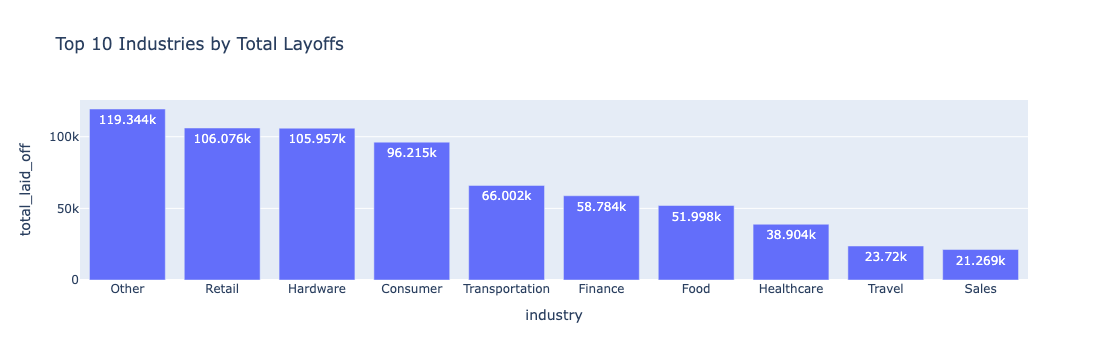

In [6]:
fig = px.bar(
    industry_layoffs.head(10),
    x="industry",
    y="total_laid_off",
    title="Top 10 Industries by Total Layoffs",
    text_auto=True
)

fig.show()

In [7]:
monthly_layoffs = (
    df.groupby("year_month")["total_laid_off"]
    .sum()
    .reset_index()
)

monthly_layoffs.head()

,year_month,total_laid_off
0,2020-03,9628.0
1,2020-04,26710.0
2,2020-05,25804.0
3,2020-06,7627.0
4,2020-07,7112.0


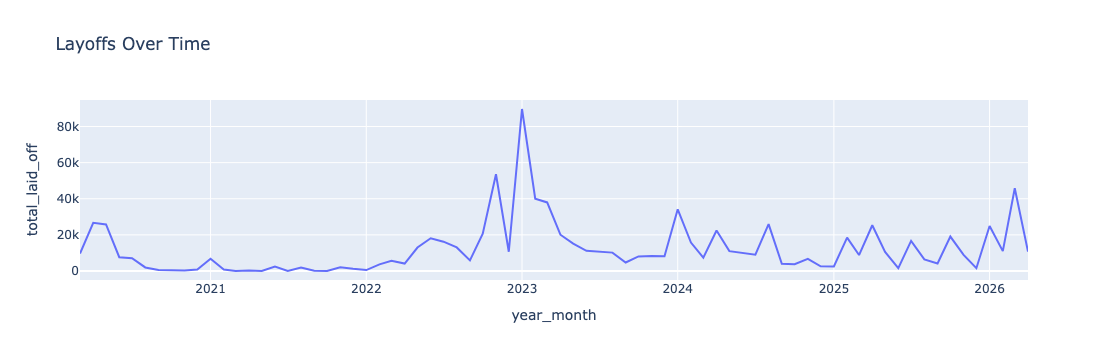

In [8]:
fig = px.line(
    monthly_layoffs,
    x="year_month",
    y="total_laid_off",
    title="Layoffs Over Time"
)

fig.show()

In [9]:
country_layoffs = (
    df.groupby("country")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_layoffs.head(10)

,country,total_laid_off
0,United States,637549.0
1,India,65704.0
2,Germany,31588.0
3,United Kingdom,23354.0
4,Netherlands,21575.0
5,Sweden,20159.0
6,Canada,16002.0
7,Israel,13107.0
8,Brazil,11939.0
9,China,8190.0


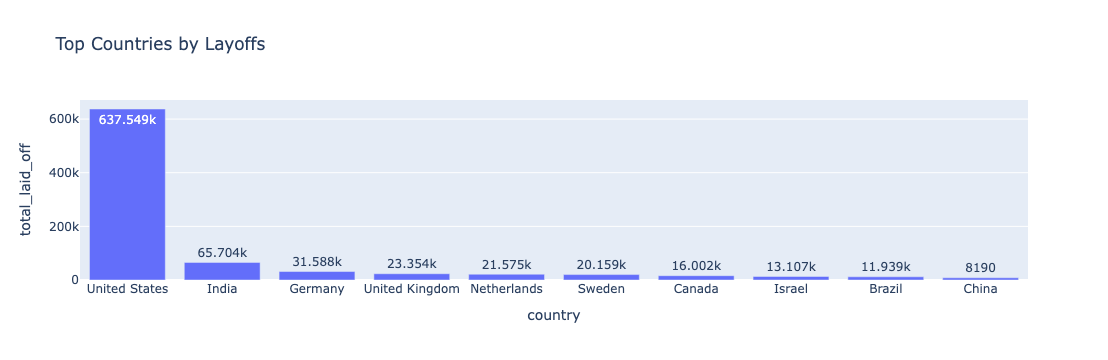

In [10]:
fig = px.bar(
    country_layoffs.head(10),
    x="country",
    y="total_laid_off",
    title="Top Countries by Layoffs",
    text_auto=True
)

fig.show()

In [11]:
largest_layoffs = (
    df.sort_values(by="total_laid_off", ascending=False)
    [["company", "industry", "country", "total_laid_off", "date"]]
)

largest_layoffs.head(10)

,company,industry,country,total_laid_off,date
22,Oracle,Other,United States,30000.0,2026-03-31
314,Intel,Hardware,United States,22000.0,2025-04-23
82,Amazon,Retail,United States,16000.0,2026-01-28
630,Intel,Hardware,United States,15000.0,2024-08-01
153,Amazon,Retail,United States,14000.0,2025-10-27
796,Tesla,Transportation,United States,14000.0,2024-04-15
2265,Google,Consumer,United States,12000.0,2023-01-20
2749,Meta,Consumer,United States,11000.0,2022-11-09
38,Dell,Hardware,United States,11000.0,2026-03-16
2298,Microsoft,Other,United States,10000.0,2023-01-18


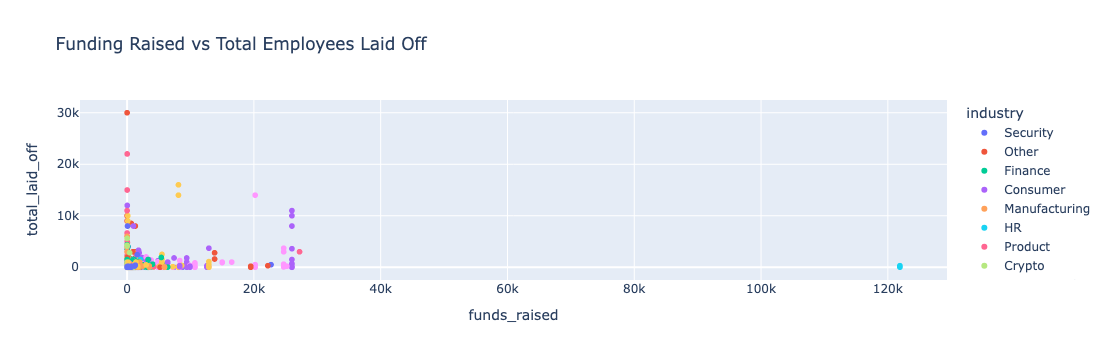

In [12]:
fig = px.scatter(
    df,
    x="funds_raised",
    y="total_laid_off",
    color="industry",
    hover_data=["company"],
    title="Funding Raised vs Total Employees Laid Off"
)

fig.show()

In [13]:
stage_analysis = (
    df.groupby("stage")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

stage_analysis.head(10)

,stage,total_laid_off
0,Post-IPO,564932.0
1,Unknown,79630.0
2,Acquired,71753.0
3,Series B,30822.0
4,Series C,27472.0
5,Series D,27094.0
6,Series E,24798.0
7,Series F,16671.0
8,Private Equity,12826.0
9,Series A,9147.0


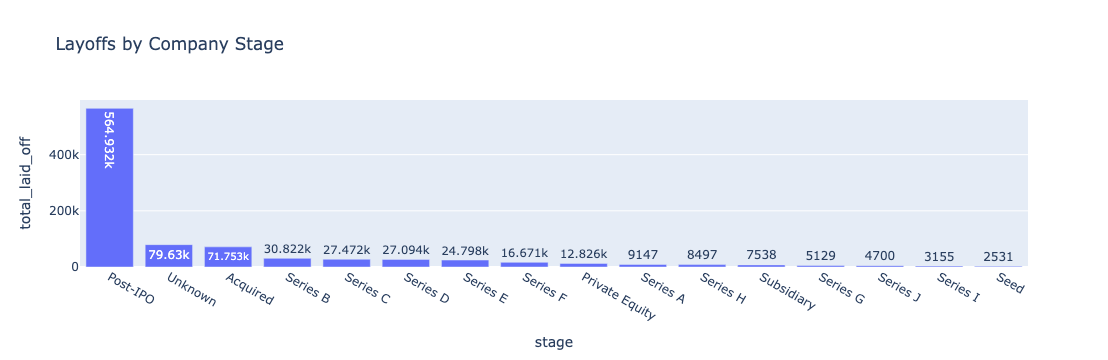

In [14]:
fig = px.bar(
    stage_analysis,
    x="stage",
    y="total_laid_off",
    title="Layoffs by Company Stage",
    text_auto=True
)

fig.show()

Example Findings
Insight 1

“Technology and consumer-focused industries experienced the highest workforce reductions during the observed period.”

Insight 2

“Several highly funded firms still conducted large-scale layoffs, suggesting that funding alone did not guarantee workforce stability.”

Insight 3

“Post-IPO firms showed significant workforce restructuring activity compared to earlier-stage startups.”

In [15]:
import numpy as np

df["severity_score"] = (
    (df["percentage_laid_off"] * 100)
    + np.log1p(df["total_laid_off"])
)

In [16]:
severity_companies = (
    df.sort_values(by="severity_score", ascending=False)
    [["company", "industry", "country",
      "total_laid_off",
      "percentage_laid_off",
      "severity_score"]]
)

severity_companies.head(15)

,company,industry,country,total_laid_off,percentage_laid_off,severity_score
3701,Katerra,Construction,United States,2434.0,1.0,107.797702
439,Lilium,Aerospace,Germany,1000.0,1.0,106.908755
659,Redbox,Media,United States,1000.0,1.0,106.908755
3307,Butler Hospitality,Food,United States,1000.0,1.0,106.908755
1617,Bitwise,Crypto,United States,900.0,1.0,106.803505
1106,Zulily,Retail,United States,839.0,1.0,106.733402
3912,Deliv,Retail,United States,669.0,1.0,106.507278
537,Eaze,Consumer,United States,500.0,1.0,106.216606
3930,Jump,Transportation,United States,500.0,1.0,106.216606
1220,Convoy,Logistics,United States,500.0,1.0,106.216606


In [17]:
industry_instability = (
    df.groupby("industry")
    .agg({
        "total_laid_off": "sum",
        "company": "nunique",
        "percentage_laid_off": "mean"
    })
    .reset_index()
)

industry_instability.columns = [
    "industry",
    "total_laid_off",
    "affected_companies",
    "avg_percentage_laid_off"
]

industry_instability.head()

,industry,total_laid_off,affected_companies,avg_percentage_laid_off
0,AI,1532.0,27,0.243103
1,Aerospace,3472.0,16,0.283750
2,Construction,3977.0,18,0.248800
3,Consumer,96215.0,167,0.159189
4,Crypto,14706.0,118,0.237358


In [18]:
industry_instability["instability_score"] = (
    industry_instability["total_laid_off"] * 0.5
    + industry_instability["affected_companies"] * 100
    + industry_instability["avg_percentage_laid_off"] * 1000
)

In [19]:
industry_instability = industry_instability.sort_values(
    by="instability_score",
    ascending=False
)

industry_instability.head(10)

,industry,total_laid_off,affected_companies,avg_percentage_laid_off,instability_score
20,Other,119344.0,190,0.161554,78833.554054
24,Retail,106076.0,231,0.191862,76329.862464
8,Finance,58784.0,382,0.199451,67791.450867
3,Consumer,96215.0,167,0.159189,64966.689189
12,Hardware,105957.0,44,0.085256,57463.756410
28,Transportation,66002.0,152,0.203546,48404.546468
13,Healthcare,38904.0,243,0.228712,43980.711656
10,Food,51998.0,157,0.255567,41954.566802
18,Marketing,14735.0,153,0.143815,22811.315166
6,Education,20802.0,101,0.196646,20697.645963


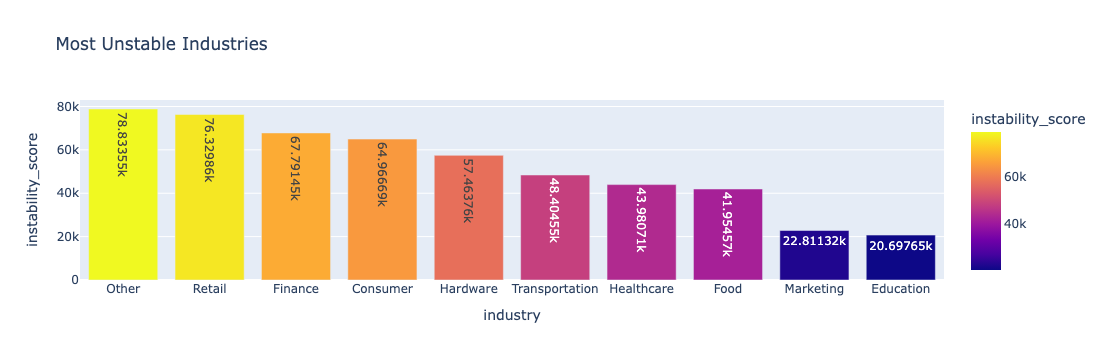

In [20]:
fig = px.bar(
    industry_instability.head(10),
    x="industry",
    y="instability_score",
    title="Most Unstable Industries",
    color="instability_score",
    text_auto=True
)

fig.show()

In [21]:
ai_keywords = [
    "AI",
    "Artificial Intelligence",
    "Machine Learning"
]

df["ai_related"] = df["industry"].apply(
    lambda x: "AI Related"
    if any(keyword.lower() in str(x).lower() for keyword in ai_keywords)
    else "Non-AI"
)

In [22]:
ai_analysis = (
    df.groupby("ai_related")["total_laid_off"]
    .sum()
    .reset_index()
)

ai_analysis

,ai_related,total_laid_off
0,AI Related,107608.0
1,Non-AI,789087.0


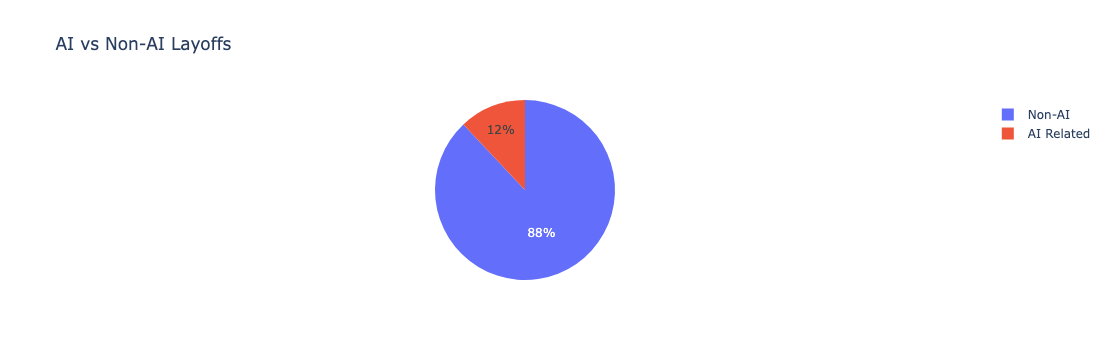

In [23]:
fig = px.pie(
    ai_analysis,
    names="ai_related",
    values="total_laid_off",
    title="AI vs Non-AI Layoffs"
)

fig.show()

In [24]:
monthly_volatility = (
    df.groupby("year_month")
    .agg({
        "total_laid_off": "sum",
        "company": "nunique"
    })
    .reset_index()
)

monthly_volatility.columns = [
    "year_month",
    "employees_laid_off",
    "affected_companies"
]

In [25]:
monthly_volatility["volatility_score"] = (
    monthly_volatility["employees_laid_off"] * 0.7
    + monthly_volatility["affected_companies"] * 100
)

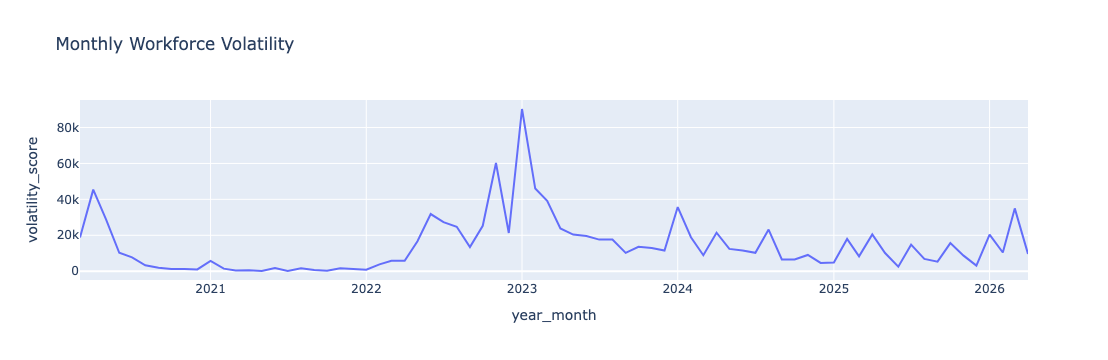

In [26]:
fig = px.line(
    monthly_volatility,
    x="year_month",
    y="volatility_score",
    title="Monthly Workforce Volatility"
)

fig.show()

In [27]:
df.to_csv(
    "../data/cleaned/layoffs_enriched.csv",
    index=False
)

print("Enriched dataset saved!")

Enriched dataset saved!
